Risk Classifcation 

In [1]:
!pip install xgboost lightgbm catboost scikit-learn pandas matplotlib seaborn joblib 

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.6 MB/s  0:00:00
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 3.1 MB/s eta 0:00:33
    --------------------------------------- 1.3/100.2 MB 3.3 MB/s eta 0:00:30
    --------------------------------------- 1.8/100.2 MB 3.3 MB/s eta 0:00:30
   - -------------------------------------- 2.6/100.2 MB 3.4 MB/s eta 0:00:29
   - -------------------------------------- 3.4/100.2 MB 3.4 MB/s eta 0:00:29
   - -------------------------------------- 4.2/100.2 MB 3.5 MB/s eta 0:00:28
   - -------------------------------------- 4.7/100.2 MB 3.4 MB/s eta 0:00:28
   -- ------------------------------------- 5.5/100.2 MB 3.4 MB/s eta 0:00:28
   -- ------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Imports of all needed data, files and modules


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("Diabetes_and_Lifestyle_Dataset_.csv")

# Quick inspection
print(df.shape)
print(df['diabetes_stage'].value_counts())
print(df.isnull().sum())
le = LabelEncoder()
df['diabetes_stage_encoded'] = le.fit_transform(df['diabetes_stage'])
X = df.drop(columns=['diabetes_stage', 'diabetes_stage_encoded'])
y = df['diabetes_stage_encoded']
# Encode any remaining categorical columns
X = pd.get_dummies(X)

(97297, 31)
diabetes_stage
Type 2          58163
Pre-Diabetes    31013
No Diabetes      7737
Gestational       267
Type 1            117
Name: count, dtype: int64
Age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                    

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
#y = le.fit_transform(y)

for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
le = LabelEncoder()
y = le.fit_transform(df['diabetes_stage'])
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Train: (77837, 48), Test: (19460, 48)
Class mapping: {'Gestational': np.int64(0), 'No Diabetes': np.int64(1), 'Pre-Diabetes': np.int64(2), 'Type 1': np.int64(3), 'Type 2': np.int64(4)}


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y           # keeps class proportions in both splits
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

Training samples: 77837
Test samples:     19460


In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Confirm it balanced the classes
print(pd.Series(y_train_bal).value_counts())

diabetes_stage_encoded
2    46530
1    46530
4    46530
0    46530
3    46530
Name: count, dtype: int64


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)  

Decision Tree

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt = DecisionTreeClassifier(
    max_depth=5,          # controls how deep the tree grows
    min_samples_split=10, # min samples needed to split a node
    random_state=42
)
le = LabelEncoder()
y = le.fit_transform(df['diabetes_stage'])
X = df.drop(columns=['diabetes_stage'])
dt.fit(X_train_bal, y_train_bal)       # train
y_pred_dt = dt.predict(X_test)        # predict on test set

best_dt = dt  # Assign best_dt for cross-validation

print("DECISION TREE RESULTS")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))


DECISION TREE RESULTS
              precision    recall  f1-score   support

 Gestational       0.01      0.72      0.03        53
 No Diabetes       0.99      0.97      0.98      1548
Pre-Diabetes       0.99      0.66      0.79      6203
      Type 1       0.01      0.30      0.01        23
      Type 2       1.00      0.85      0.92     11633

    accuracy                           0.80     19460
   macro avg       0.60      0.70      0.55     19460
weighted avg       0.99      0.80      0.88     19460



 Tuned Decision Tree

In [ ]:
"""
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5],

    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,                    # 5-fold cross validation
    scoring='f1_weighted',   # optimise for weighted F1
    n_jobs=4,                # use 4 cores instead of all (-1)
    verbose=1
)

dt_grid.fit(X_train_bal, y_train_bal)

print("Best DT params:", dt_grid.best_params_)
print("Best DT score: ", dt_grid.best_score_)

# Use the best version
best_dt = dt_grid.best_estimator_
"""

_IncompleteInputError: incomplete input (757939289.py, line 28)

Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,    # number of trees
    max_depth=10,        # max depth per tree
    random_state=42,
    n_jobs=-1            # use all CPU cores
)

rf.fit(X_train_bal, y_train_bal)
y_pred_rf = rf.predict(X_test)

best_rf = rf  # Assign best_rf for cross-validation

print("RANDOM FOREST RESULTS")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

 Gestational       0.02      0.28      0.03        53
 No Diabetes       0.98      0.97      0.98      1548
Pre-Diabetes       0.99      0.94      0.96      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       1.00      0.95      0.97     11633

    accuracy                           0.95     19460
   macro avg       0.60      0.63      0.59     19460
weighted avg       0.99      0.95      0.97     19460



Tuned Random Forest

In [ ]:
"""
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=5, # 5-fold cross validation
    scoring='f1_weighted',  # optimise for weighted F1
    n_jobs=-1,       # use 1 core instead of all (-1)
    verbose=1
)

rf_grid.fit(X_train_bal, y_train_bal)

print("Best RF params:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_ """

Xgboost

In [25]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb.fit(X_train_bal, y_train_bal)
best_xgb = xgb

y_pred_xgb = best_xgb.predict(X_test)

print("XGBOOST RESULTS")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))


c:\Users\tsheg\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:05:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBOOST RESULTS
              precision    recall  f1-score   support

 Gestational       0.03      0.04      0.03        53
 No Diabetes       0.99      0.99      0.99      1548
Pre-Diabetes       0.99      0.99      0.99      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       1.00      1.00      1.00     11633

    accuracy                           0.99     19460
   macro avg       0.60      0.60      0.60     19460
weighted avg       0.99      0.99      0.99     19460



Tuned XGboost model


In [ ]:
"""
from xgboost import XGBClassifier

xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', 
                  use_label_encoder=False),
    xgb_params,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_bal, y_train_bal)

print("Best XGB params:", xgb_grid.best_params_)
best_xgb = xgb_grid.best_estimator_ """

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


Comparison Between Models

In [18]:
from sklearn.model_selection import cross_val_score

for name, model in [('Decision Tree', best_dt), 
                     ('Random Forest', best_rf), 
                     ('XGBoost', best_xgb)]:
    
    scores = cross_val_score(model, X_train_bal, y_train_bal, 
                             cv=5, scoring='f1_weighted')
    
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")
    

Decision Tree: 0.8041 (+/- 0.0039)
Random Forest: 0.9582 (+/- 0.0072)


c:\Users\tsheg\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:02:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tsheg\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:02:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tsheg\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:02:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tsheg\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:02:48] WARNING: C:\actio

XGBoost: 0.9853 (+/- 0.0085)


Model                  Accuracy   F1 (weighted)
-----------------------------------------------
Decision Tree            0.8002          0.8814
Random Forest            0.9452          0.9668
XGBoost                  0.9915          0.9917
               Accuracy  F1 Weighted
Decision Tree  0.800206     0.881403
Random Forest  0.945221     0.966815
XGBoost        0.991470     0.991730


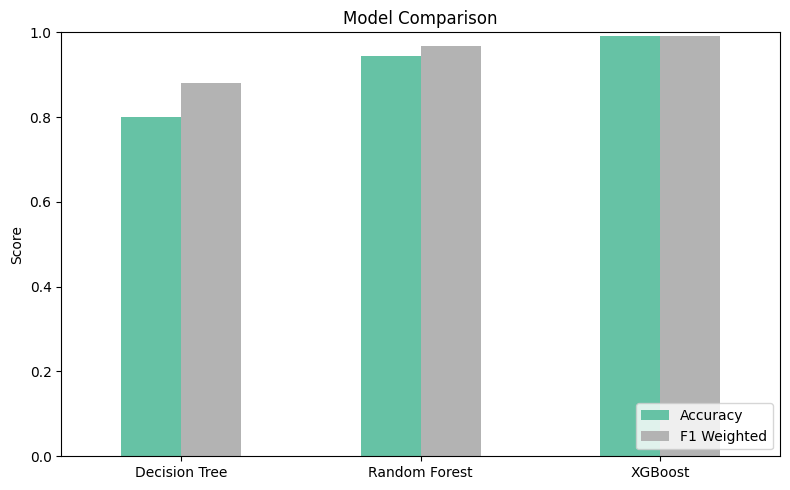

In [20]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'XGBoost':       y_pred_xgb
}

results = {}

print(f"{'Model':<20} {'Accuracy':>10} {'F1 (weighted)':>15}")
print("-" * 47)
for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    results[name] = {'Accuracy': acc, 'F1 Weighted': f1}
    print(f"{name:<20} {acc:>10.4f} {f1:>15.4f}")

results_df = pd.DataFrame(results).T
print(results_df)

results_df.plot(kind='bar', figsize=(8, 5), colormap='Set2')
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [24]:
tuned_models = {
    'Decision Tree (tuned)': (best_dt, X_test),
    'Random Forest (tuned)': (best_rf, X_test),
    'XGBoost (tuned)':       (best_xgb, X_test)}

print(f"{'Model':<25} {'Accuracy':>10} {'F1 Weighted':>13}")
print("-" * 50)
for name, (model, X_eval) in tuned_models.items():
    preds = model.predict(X_eval)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    print(f"{name:<25} {acc:>10.4f} {f1:>13.4f}")

Model                       Accuracy   F1 Weighted
--------------------------------------------------
Decision Tree (tuned)         0.8002        0.8814
Random Forest (tuned)         0.9452        0.9668
XGBoost (tuned)               0.9915        0.9917


Exporting Models

In [26]:
import joblib

joblib.dump(xgb,   'models/best_classifier.pkl')   # swap for whichever won
joblib.dump(le,     'models/label_encoder.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(list(X.columns), 'models/feature_columns.pkl')


['models/feature_columns.pkl']